In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from essential_functions import scatter_comparison_train_test_plot, feature_importance_plot, descriptive_statistics
import warnings
warnings.filterwarnings('ignore')

/Users/danmayonde/Desktop/ML_Master_Project/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The output directory of all the files saved in this notebook
output_path = os.path.join('..', 'feature_importance')

In [3]:
# Load Data

df = ((pd.read_csv("../Data/BData.csv")).drop(columns=["Sample_ID"])).dropna()

# Transform Aspect to Sine and Cosine
aspect_rad = np.radians(df["Aspect (˚)"])   # Convert to radians

# Insert the two new features next to "Aspect (˚)"
df.insert(5, "aspect_sin", np.sin(aspect_rad))
df.insert(6, "aspect_cos", np.cos(aspect_rad))

# Drop "Aspect (˚)" from the data frame
df.drop(["Aspect (˚)"], axis=1, inplace=True)

# Encode the Categorical Feature "Land Use" to 1 for "residential" and 0 for "barren"
df["Land Use"] = (df["Land Use"] == "residential").astype(int)

df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,0.0655,0,2473,1535,...,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,0.0684,0,2507,1533,...,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,0.0672,0,2529,1521,...,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,0.0590,0,2559,1511,...,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,0.0593,0,2511,1470,...,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931,26.657,8.338


## Log Transformation

In [4]:
# Log10 Transformation
print('/.. run log transformation...')
# Variables to transform
feat_transform = ["Clay (%)", "TDS (mg/L)", "SOM (g/kg)", 'NDVI']

# log10 transformation of variables
for feature in feat_transform:
    df[feature] = np.log10(df[feature])

print('feature transformation complete...')  

/.. run log transformation...
feature transformation complete...


In [5]:
df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,-1.183759,0,2473,1535,...,91.2,7.6,0.079181,7.3,100.0,1.698970,0.193125,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,-1.164944,0,2507,1533,...,87.9,10.4,0.204120,7.9,137.0,1.832509,0.217484,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,-1.172631,0,2529,1521,...,91.8,7.0,0.113943,7.1,109.0,1.736397,0.418301,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,-1.229148,0,2559,1511,...,89.7,8.8,0.176091,7.5,90.0,1.648360,0.352183,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,-1.226945,0,2511,1470,...,86.4,12.0,0.204120,8.0,119.0,1.774517,0.326336,384.931,26.657,8.338


In [6]:
targets = ['Cu (mg/kg)', 'Zn (mg/kg)', 'Pb (mg/kg)']
redundant_features = ["Longitude", "Latitude", "Dist_Main_Road  (m)", "EC (µs/cm)", "Sand (%)"]

features_to_drop = targets + redundant_features

# Create X Data and y

X = df.drop(columns=features_to_drop).copy()

y = df[targets].copy()

feature_cols = X.columns

y.head()

,Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,247.980,30.210,9.123
1,359.081,31.586,8.282
2,243.819,31.527,5.749
3,314.907,34.707,9.071
4,384.931,26.657,8.338


In [7]:
numeric_features = ['Slope (%)', 'Elevation (m)', 'aspect_sin', 'aspect_cos', 'NDVI', 'Dist_Near_Road (m)', 'Dist_Tailing (m)', 'Silt (%)',
       'Clay (%)', 'pH', 'TDS (mg/L)', 'SOM (g/kg)']
categorical_features = ['Land Use']


In [8]:
# Preprocesser Scaler that leaves the categorical features unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)  # leave as-is
    ]
)

# scoring metrics to be used for cross validation
scoring = {'r2': 'r2',
          'mae': 'neg_mean_absolute_error',
          'rmse': 'neg_root_mean_squared_error'
          }

## Split The Dataset Into Training an Test Set

In [9]:
# Split the DataSet into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sperating targets array into different arrays
y_train_Cu = y_train[targets[0]]
y_train_Zn = y_train[targets[1]]
y_train_Pb = y_train[targets[2]]

y_test_Cu = y_test[targets[0]]
y_test_Zn = y_test[targets[1]]
y_test_Pb = y_test[targets[2]]

# PREDICTION OF Cu CONCENTRATIONS

In [10]:
# Load the SVR Model
svr_model_Cu = SVR(C=1.67,
                   kernel='linear',
                  degree=3,   
                  epsilon=0.2,
                  gamma='scale')

# Define the pipeline
svr_pipeline_Cu = Pipeline([
    ('scaler', preprocessor),
    ('svr', svr_model_Cu)
])

svr_Cu = TransformedTargetRegressor(
    regressor=svr_pipeline_Cu,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
svr_Cu.fit(X_train, y_train_Cu)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        svr_Cu, X_train, y_train_Cu, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Cu = svr_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.1859
MAE: 50.7277
RMSE: 78.8346

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.2102
MAE: 46.6199
RMSE: 84.5168


In [11]:
# Predict on the test set
y_pred_Cu = svr_Cu.predict(X_test)

r2 = r2_score(y_test_Cu, y_pred_Cu)
mae = mean_absolute_error(y_test_Cu, y_pred_Cu)
rmse = np.sqrt(mean_squared_error(y_test_Cu, y_pred_Cu))

# Predicting on the training set
y_train_pred_Cu = svr_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.2008
MAE: 54.4304
RMSE: 75.0524

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.2102
MAE: 46.6199
RMSE: 84.5168


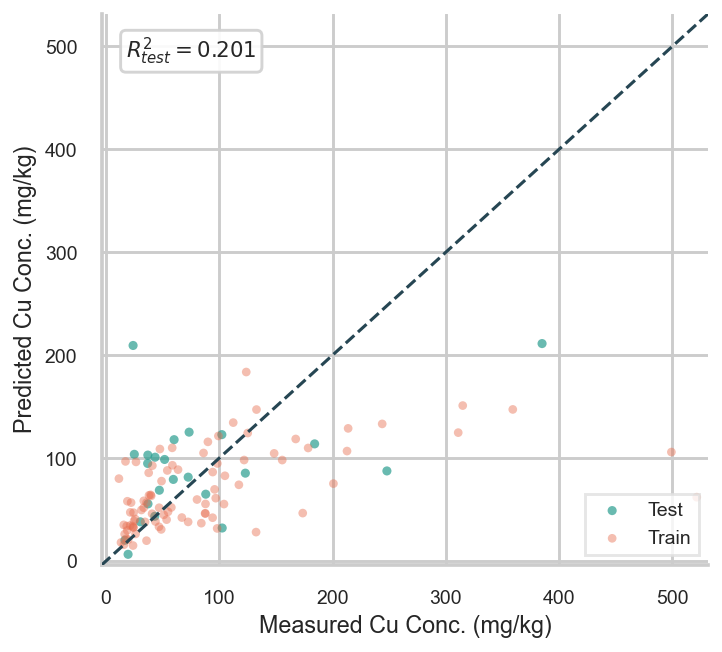

In [12]:
scatter_comparison_train_test_plot(y_pred_Cu,
                                  y_test_Cu,
                                  y_train_pred_Cu,
                                  y_train_Cu,
                                  x_label='Measured Cu Conc. (mg/kg)',
                                  y_label='Predicted Cu Conc. (mg/kg)',
                                  file_name='Cu_pred_vs_true_svr.png')

In [13]:
# Wrap full pipeline predict
def predict_fn(X):
    return svr_Cu.predict(pd.DataFrame(X, columns=X_train.columns))
    
np.random.seed(42)
explainer_Cu   = shap.KernelExplainer(predict_fn, X_train)
shap_values_Cu = explainer_Cu.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Cu = {}

# Store results
shap_results_Cu[targets[0]] = {
    'explainer': explainer_Cu,
    'shap_values': shap_values_Cu,
    'model': svr_Cu
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Cu = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Cu).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Cu["Contribution (%)"] = (
    shap_importance_Cu["Mean_|SHAP|"] / shap_importance_Cu["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Cu['Cumulative (%)'] = shap_importance_Cu["Contribution (%)"].cumsum()

safe_name = targets[0].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Cu_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[0]} (by Mean |SHAP|):")
print(shap_importance_Cu.to_string(index=False))

shap_importance_Cu.to_csv(f'{importance_Cu_path}_svr.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:05<00:00,  4.15it/s]


  Important Features for Cu (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
  Dist_Tailing (m)    34.204006             22.15           22.15
          Silt (%)    25.625592             16.60           38.75
          Land Use    20.501850             13.28           52.03
     Elevation (m)    18.271504             11.83           63.86
          Clay (%)    14.601535              9.46           73.32
        TDS (mg/L)    11.457477              7.42           80.74
        aspect_sin     8.049383              5.21           85.95
        SOM (g/kg)     7.213437              4.67           90.62
              NDVI     5.320369              3.45           94.07
Dist_Near_Road (m)     4.941754              3.20           97.27
        aspect_cos     2.747509              1.78           99.05
         Slope (%)     1.464651              0.95          100.00
                pH     0.000000              0.00          100.00


# PREDICTION of Zn CONCENTRATIONS

In [14]:
# Load the SVR Model
svr_model_Zn = SVR(C=1.7,
                   kernel='rbf',
                   degree=3,
                   epsilon=0.22,
                   gamma=0.015
                  )

# Define the pipeline
svr_pipeline_Zn = Pipeline([
    ('scaler', preprocessor),
    ('svr', svr_model_Zn)
])

svr_Zn = TransformedTargetRegressor(
    regressor=svr_pipeline_Zn,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
svr_Zn.fit(X_train, y_train_Zn)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        svr_Zn, X_train, y_train_Zn, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Zn = svr_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0939
MAE: 10.4567
RMSE: 14.7188

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3137
MAE: 9.4334
RMSE: 14.5851


In [15]:
# Predict on the test set
y_pred_Zn = svr_Zn.predict(X_test)

r2 = r2_score(y_test_Zn, y_pred_Zn)
mae = mean_absolute_error(y_test_Zn, y_pred_Zn)
rmse = np.sqrt(mean_squared_error(y_test_Zn, y_pred_Zn))

# Predicting on the training set
y_train_pred_Zn = svr_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.0260
MAE: 8.5724
RMSE: 11.2171

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3137
MAE: 9.4334
RMSE: 14.5851


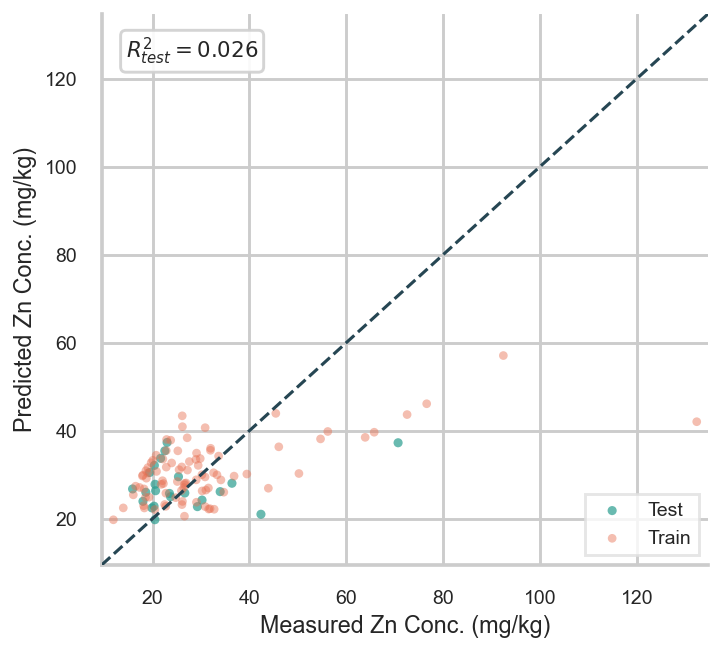

In [16]:
# Plot the scatter plot Predicted vs True Zn Conc.
scatter_comparison_train_test_plot(y_pred_Zn,
                                  y_test_Zn,
                                  y_train_pred_Zn,
                                  y_train_Zn,
                                  x_label='Measured Zn Conc. (mg/kg)',
                                  y_label='Predicted Zn Conc. (mg/kg)',
                                  file_name='Zn_pred_vs_true_svr.png')

In [17]:
# Wrap full pipeline predict
def predict_fn(X):
    return svr_Zn.predict(pd.DataFrame(X, columns=X_train.columns))
    
np.random.seed(42)
explainer_Zn   = shap.KernelExplainer(predict_fn, X_train)
shap_values_Zn = explainer_Zn.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Zn = {}

# Store results
shap_results_Zn[targets[1]] = {
    'explainer': explainer_Zn,
    'shap_values': shap_values_Zn,
    'model': svr_Zn
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Zn = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Zn).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Zn["Contribution (%)"] = (
    shap_importance_Zn["Mean_|SHAP|"] / shap_importance_Zn["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Zn['Cumulative (%)'] = shap_importance_Zn["Contribution (%)"].cumsum()

safe_name = targets[1].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Zn_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[1]} (by Mean |SHAP|):")
print(shap_importance_Zn.to_string(index=False))

shap_importance_Zn.to_csv(f'{importance_Zn_path}_svr.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:04<00:00,  5.31it/s]


  Important Features for Zn (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
        SOM (g/kg)     3.672782             27.96           27.96
          Clay (%)     1.786011             13.60           41.56
     Elevation (m)     1.644119             12.52           54.08
  Dist_Tailing (m)     1.282536              9.76           63.84
         Slope (%)     0.851927              6.48           70.32
Dist_Near_Road (m)     0.846866              6.45           76.77
                pH     0.682819              5.20           81.97
        aspect_cos     0.622460              4.74           86.71
          Land Use     0.567835              4.32           91.03
          Silt (%)     0.468100              3.56           94.59
              NDVI     0.442976              3.37           97.96
        TDS (mg/L)     0.216203              1.65           99.61
        aspect_sin     0.052270              0.40          100.01


# PREDICTION OF Pb CONCENTRATIONS

In [18]:
#Load the SVR Model
svr_model_Pb = SVR(C=0.25,
                   kernel='rbf',
                   degree=3,
                   epsilon=0.15,
                   gamma=0.1
    
)

# Define the pipeline
svr_pipeline_Pb = Pipeline([
    ('scaler', preprocessor),
    ('svr', svr_model_Pb)
])

svr_Pb = TransformedTargetRegressor(
    regressor=svr_pipeline_Pb,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
svr_Pb.fit(X_train, y_train_Pb)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        svr_Pb, X_train, y_train_Pb, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Pb = svr_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0315
MAE: 4.6849
RMSE: 8.2231

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3557
MAE: 3.6719
RMSE: 7.6554


In [19]:
# Predict on the test set
y_pred_Pb = svr_Pb.predict(X_test)

r2 = r2_score(y_test_Pb, y_pred_Pb)
mae = mean_absolute_error(y_test_Pb, y_pred_Pb)
rmse = np.sqrt(mean_squared_error(y_test_Pb, y_pred_Pb))

# Predicting on the training set
y_train_pred_Pb = svr_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.2035
MAE: 3.6000
RMSE: 9.6669

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3557
MAE: 3.6719
RMSE: 7.6554


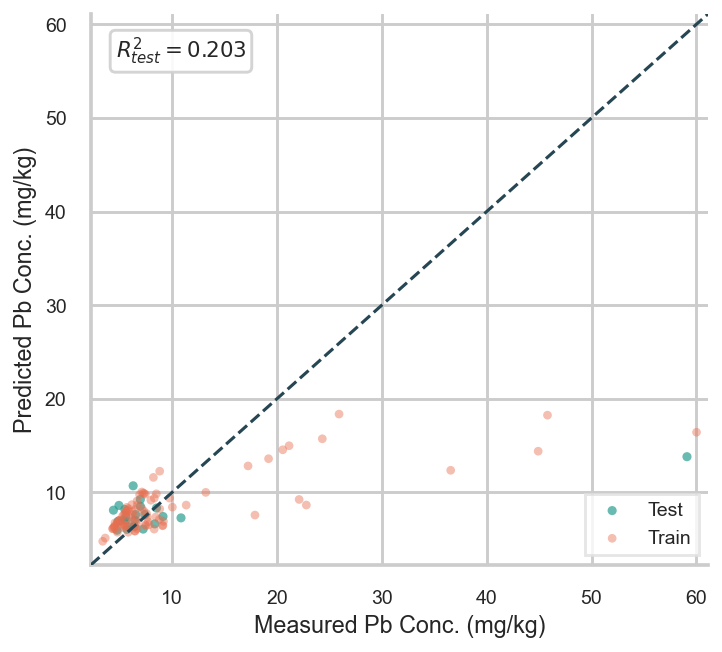

In [20]:
# Plot the scatter plot Predicted vs True Pb Conc.
scatter_comparison_train_test_plot(y_pred_Pb,
                                  y_test_Pb,
                                  y_train_pred_Pb,
                                  y_train_Pb,
                                  x_label='Measured Pb Conc. (mg/kg)',
                                  y_label='Predicted Pb Conc. (mg/kg)',
                                  file_name='Pb_pred_vs_true_svr.png')

In [21]:
# Wrap full pipeline predict
def predict_fn(X):
    return svr_Pb.predict(pd.DataFrame(X, columns=X_train.columns))
    
np.random.seed(42)
explainer_Pb   = shap.KernelExplainer(predict_fn, X_train)
shap_values_Pb = explainer_Pb.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Pb = {}

# Store results
shap_results_Pb[targets[2]] = {
    'explainer': explainer_Pb,
    'shap_values': shap_values_Pb,
    'model': svr_Pb
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Pb = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Pb).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Pb["Contribution (%)"] = (
    shap_importance_Pb["Mean_|SHAP|"] / shap_importance_Pb["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Pb['Cumulative (%)'] = shap_importance_Pb["Contribution (%)"].cumsum()

safe_name = targets[2].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Pb_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[2]} (by Mean |SHAP|):")
print(shap_importance_Pb.to_string(index=False))

shap_importance_Pb.to_csv(f'{importance_Pb_path}_svr.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:08<00:00,  2.75it/s]


  Important Features for Pb (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
  Dist_Tailing (m)     0.447343             13.95           13.95
Dist_Near_Road (m)     0.433561             13.52           27.47
          Clay (%)     0.393606             12.28           39.75
         Slope (%)     0.389253             12.14           51.89
     Elevation (m)     0.310978              9.70           61.59
                pH     0.279791              8.73           70.32
        TDS (mg/L)     0.244080              7.61           77.93
        SOM (g/kg)     0.187572              5.85           83.78
          Silt (%)     0.169391              5.28           89.06
              NDVI     0.144751              4.51           93.57
        aspect_sin     0.088432              2.76           96.33
        aspect_cos     0.068951              2.15           98.48
          Land Use     0.048533              1.51           99.99


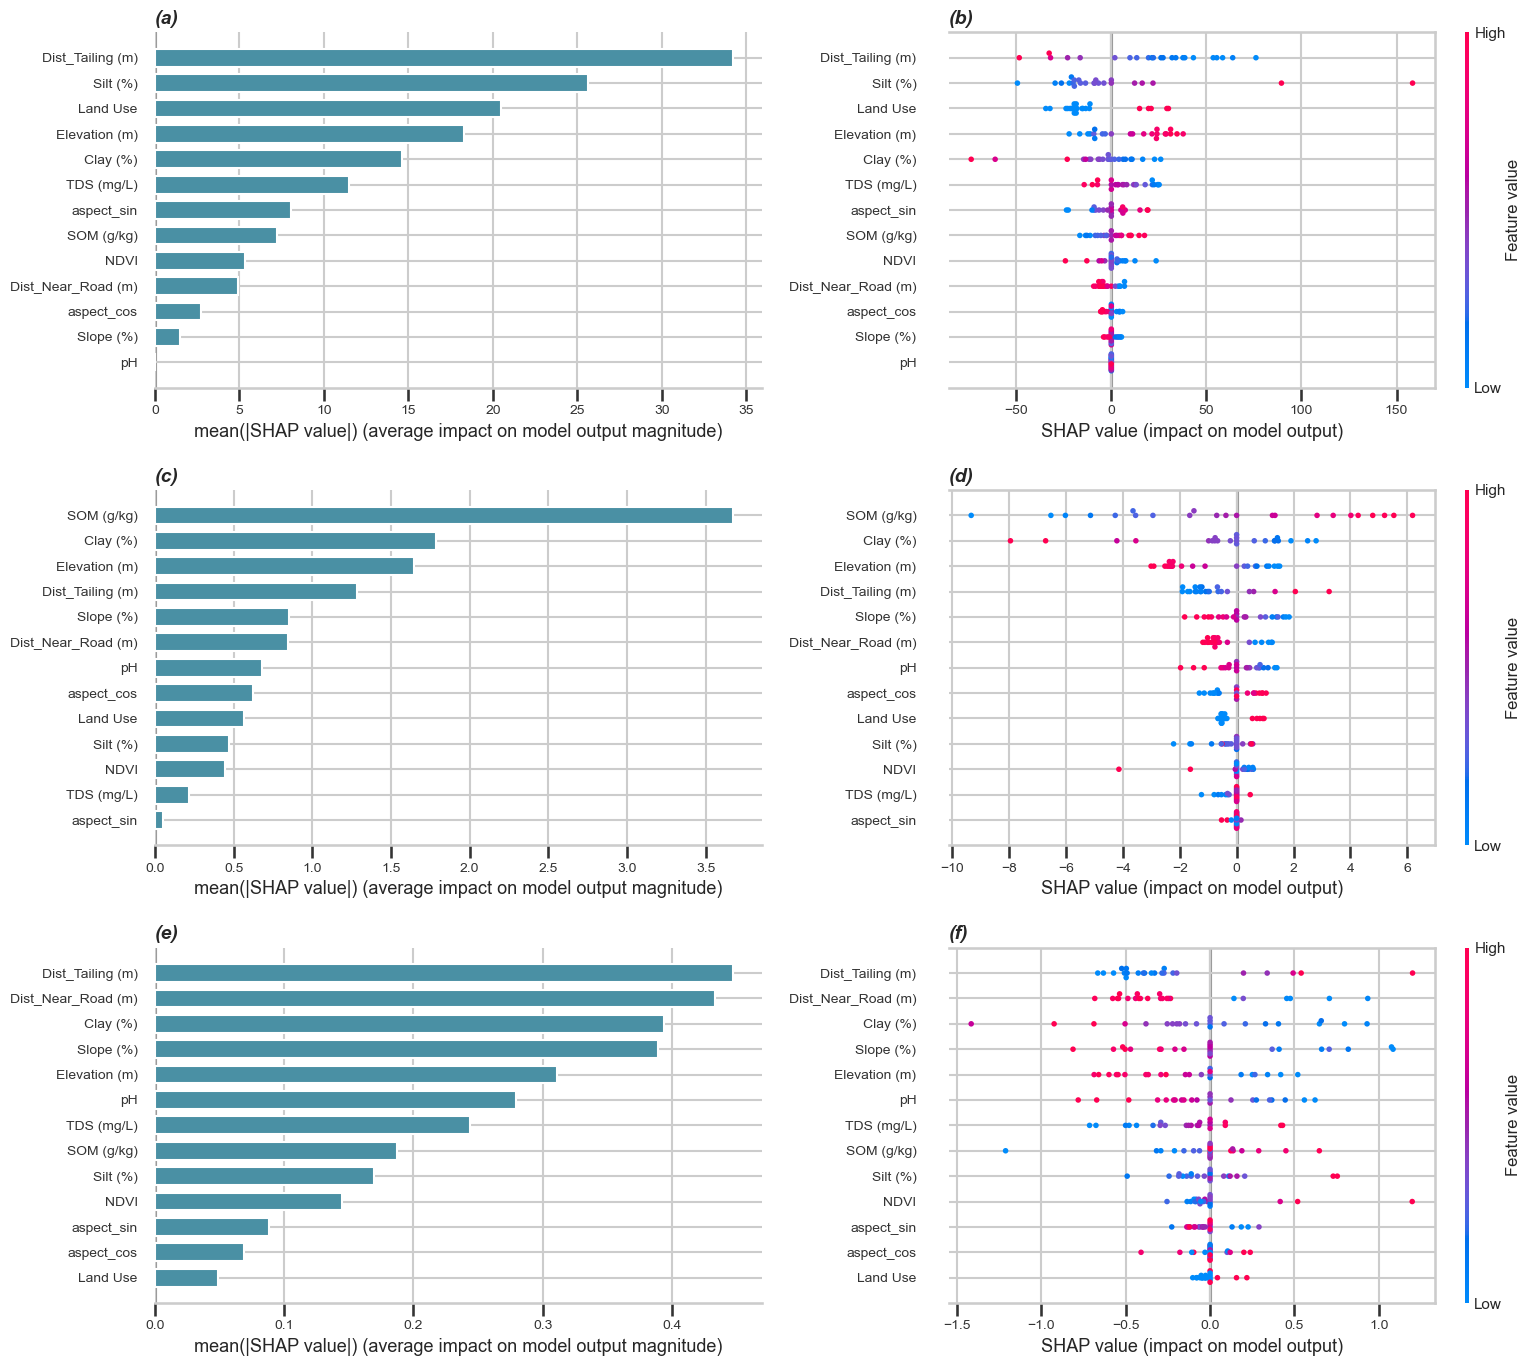

In [22]:
feature_importance_plot(X_test,
                        shap_values_Cu,
                        shap_values_Zn,
                        shap_values_Pb,
                        plot_name="Shap_Feature_Importance_Summary_Cu_Zn_Pb_SVR.png")
